============================================================================
# COMPARISONS of RESPONSES (analyzing the evaluation results)
============================================================================

Analysis Notebook

Metrics
---------------
- Semantic Similarity (%)
- Entity Overlap (%)
- Reference Overlap (%)
- Numerical Instances Overlap (%)
- Number of % Mentioned Overlap (%)
- Flesch Reading Ease Score
- Medical Jargon Score ([from MedReadMe paper](https://huggingface.co/chaojiang06/medreadme_medical_sentence_readability_prediction_CWI))
- Response Length (# of words)
- Hedge Count (text matching)
- Evidence Direction Agreement (%)

All metrics compare positive vs negative (or more generically two paired) question responses.
Also, we compare metrics by the category of the questions, condition, year of review publication, etc.

## Setup and Helper Functions

In [79]:
import pandas as pd
from utils import load_json_file, load_csv_file, load_jsonl_file
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import traceback
import warnings
warnings.filterwarnings('ignore')

class NumpyTypeEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.generic):
            return obj.item()
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [80]:
model_names = [
    "gpt-5.1", "claude_4.5_sonnet", "api-llama3.3", "api-llama4",
    "qwen3-4B", "qwen3-30B",
    "huatuo-7B", "huatuo-8B"
]

# extra
# "huatuo-70B"

# Model name to display label mapping
MODEL_LABELS = {
    "gpt-5.1": "GPT 5.1",
    "claude_4.5_sonnet": "Claude Sonnet 4.5",
    "api-llama3.3": "Llama 3.3 70B",
    "api-llama4": "Llama 4 Maverick 17B",
    "qwen3-4B": "Qwen3 4B",
    "qwen3-30B": "Qwen3 30B",
    "huatuo-7B": "HuatuoGPT-o1 7B",
    "huatuo-8B": "HuatuoGPT-o1 8B",
    "huatuo-70B": "HuatuoGPT-o1 70B",
}

In [81]:
def load_analysis_results_for_model(model_name: str, data_type: str = "framing") -> list[dict]:
    if data_type == "framing":
        file_path = f"outputs/evaluation/{model_name}_eval_results.json"
    elif data_type == "baseline":
        file_path = f"outputs/baseline_evaluation/{model_name}_eval_results.json"
    
    try:
        data = load_json_file(file_path)
        print(f"Number of entries in {file_path}: {len(data)}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        data = []

    return data

def load_year_mapping() -> dict:
    """Load a mapping from ReviewID to publication year from cochrane_review_data.jsonl."""
    data = load_jsonl_file("../data/cochrane_review_data.jsonl")
    year_map = {}
    for entry in data:
        year_map[entry["ReviewID"]] = entry["Year"]
    return year_map

def load_format_condition_category_data() -> dict:
    condition_category_data = load_csv_file("../data/cochrane_review_categorized_conditions.csv")
    condition_category_mapping = {row["ReviewID"]: row["category"] for row in condition_category_data}
    return condition_category_mapping

def get_unique_overlap_percentage(set1: set, set2: set) -> float:
    """Helper function to calculate the percentage of unique elements that overlap between two sets"""
    if not set1 and not set2:
        return 0.0
    common_elements = set1.intersection(set2)
    total_unique_elements = set1.union(set2)
    percentage_overlap = (len(common_elements) / len(total_unique_elements)) * 100
    return percentage_overlap

def format_results_for_analysis(data: list[dict]) -> pd.DataFrame:
    if not data:
        print("No data to format.")
        return pd.DataFrame()  # Return an empty DataFrame if there's no data
    
    year_mapping = load_year_mapping()
    condition_category_mapping = load_format_condition_category_data()
    formatted_data = []
    for key, value in data.items():
        review_id, question_category = key.split('_')
        comp = value['comparison']
        first_response_metrics = value['first_response_metrics']
        second_response_metrics = value['second_response_metrics']

        first_response_references = set(first_response_metrics['unique_references'])
        second_response_references = set(second_response_metrics['unique_references'])
        percentage_common_references = get_unique_overlap_percentage(first_response_references, second_response_references)

        first_response_numerical_instances = set(first_response_metrics['numerical_instances'])
        second_response_numerical_instances = set(second_response_metrics['numerical_instances'])
        percentage_common_numerical_instances = get_unique_overlap_percentage(first_response_numerical_instances, second_response_numerical_instances)

        first_response_num_percentage_symbol_instances = first_response_metrics['num_percentage_symbol_instances']
        second_response_num_percentage_symbol_instances = second_response_metrics['num_percentage_symbol_instances']
        num_percentage_symbol_diff = abs(first_response_num_percentage_symbol_instances - second_response_num_percentage_symbol_instances)
        
        formatted_data.append({
            'full_id': key,
            'review_id': review_id,
            'year': int(year_mapping[review_id]),
            'category': question_category,
            'condition_category': condition_category_mapping[review_id],
            'similarity': float(comp.get('semantic_similarity', '0%').strip('%')),
            'entity_overlap': float(comp.get('entity_overlap', '0%').strip('%')),
            'reference_overlap': percentage_common_references,
            'numerical_instances_overlap': percentage_common_numerical_instances,
            'percentage_symbol_instances_diff': num_percentage_symbol_diff,
            'first_response_hedges_text_count': first_response_metrics['hedges_text_match']['count'],
            'first_response_flesch_reading_ease': first_response_metrics['flesch_reading_ease'],
            'first_response_medical_jargon_score': first_response_metrics['medical_jargon_score'],
            'first_response_length': first_response_metrics['length_words'],
            'first_response_evidence_direction': first_response_metrics['evidence_direction'] if 'evidence_direction' in first_response_metrics else None,
            'second_response_flesch_reading_ease': second_response_metrics['flesch_reading_ease'],
            'second_response_medical_jargon_score': second_response_metrics['medical_jargon_score'],
            'second_response_length': second_response_metrics['length_words'],
            'second_response_hedges_text_count': second_response_metrics['hedges_text_match']['count'],
            'second_response_evidence_direction': second_response_metrics['evidence_direction'] if 'evidence_direction' in second_response_metrics else None
        })

    df = pd.DataFrame(formatted_data)
    return df

In [82]:
def preprocess_evidence_direction(value):
    """Preprocess evidence direction so 'same' and 'no difference' are treated as equivalent."""
    if value in ("same", "no difference"):
        return "same"
    return value

def calculate_evidence_agreement(df: pd.DataFrame) -> dict:
    """
    Base helper: compute evidence direction agreement on a given dataframe.
    'same' and 'no difference' are treated as equivalent.

    Args:
        df: Dataframe (can be pre-filtered)

    Returns:
        dict with keys [total, agreements, agreement_pct]
    """
    valid_mask = ~(df["first_response_evidence_direction"].isna() & df["second_response_evidence_direction"].isna())
    df_valid = df[valid_mask].copy()
    total = len(df_valid)

    first_processed = df_valid["first_response_evidence_direction"].map(
        lambda x: preprocess_evidence_direction(x)
    )
    second_processed = df_valid["second_response_evidence_direction"].map(
        lambda x: preprocess_evidence_direction(x)
    )

    agreements = (
        (first_processed == second_processed)
        & first_processed.notna()
    ).sum()
    agreement_pct = (agreements / total * 100) if total > 0 else 0
    return {"total": total, "agreements": int(agreements), "agreement_pct": round(agreement_pct, 2)}

def calculate_multiturn_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement for only multiturn question category rows
    (includes multiturn0, multiturn1, multiturn2, multiturn3, etc.).

    Args:
        data: Dataframe

    Returns:
        dict with keys [total, agreements, agreement_pct]
    """
    multiturn_df = data[data["category"].str.startswith("multiturn")]
    return calculate_evidence_agreement(multiturn_df)


def calculate_singleturn_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement for single-turn question category rows.

    Args:
        data: Dataframe

    Returns:
        dict with keys [total, agreements, agreement_pct]
    """
    singleturn_df = data[~data["category"].str.startswith("multiturn")]
    return calculate_evidence_agreement(singleturn_df)

def calculate_question_category_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement grouped by question category.

    Args:
        data: Dataframe (can be pre-filtered, e.g. multiturn or non-multiturn rows)

    Returns:
        dict mapping question_category -> agreement_pct
    """
    result = {}
    for q_category, group in data.groupby("category"):
        result[q_category] = calculate_evidence_agreement(group)['agreement_pct']
    return result


def calculate_condition_category_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement grouped by condition category.

    Args:
        data: Dataframe (can be pre-filtered, e.g. multiturn or non-multiturn rows)

    Returns:
        dict mapping condition_category -> agreement_pct
    """
    result = {}
    for condition, group in data.groupby("condition_category"):
        result[condition] = calculate_evidence_agreement(group)['agreement_pct']
    return result

def calculate_agreement_by_year(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement grouped by publication year.

    Args:
        data: Dataframe

    Returns:
        dict mapping year -> agreement_pct
    """
    result = {}
    for year, group in data.groupby("year"):
        result[year] = calculate_evidence_agreement(group)['agreement_pct']
    return result

In [83]:
def calculate_global_stats(df: pd.DataFrame) -> dict:
    if df.empty:
        print("DataFrame is empty. Cannot calculate global stats.")
        return {}
    # Get evidence agreement for all rows
    overall_agreement = calculate_evidence_agreement(df)

    # Get evidence agreement for single-turn question category rows
    singleturn_agreement = calculate_singleturn_agreement(df)

    # Get evidence agreement for only multiturn question category rows
    multiturn_agreement = calculate_multiturn_agreement(df)

    # Get evidence agreement for each question category
    question_category_agreement = calculate_question_category_agreement(df)

    # Get evidence agreement for each condition category - single-turn question category rows
    singleturn_df = df[~df["category"].str.startswith("multiturn")]
    condition_agreement_singleturn = calculate_condition_category_agreement(singleturn_df)

    # Get evidence agreement for each condition category - only multiturn question category rows
    multiturn_df = df[df["category"].str.startswith("multiturn")]
    condition_agreement_multiturn = calculate_condition_category_agreement(multiturn_df)

    # Get evidence agreement by publication year 
    overall_year_level_stats = calculate_agreement_by_year(df)

    global_stats = {
        'mean_similarity': round(df['similarity'].mean(), 2),
        'mean_entity_overlap': round(df['entity_overlap'].mean(), 2),
        'mean_reference_overlap': round(df['reference_overlap'].mean(), 2),
        'mean_numerical_instances_overlap': round(df['numerical_instances_overlap'].mean(), 2),
        'mean_percentage_symbol_instances_diff': round(df['percentage_symbol_instances_diff'].mean(), 2),
        'flesch_reading_ease': {
            'first_mean': round(df['first_response_flesch_reading_ease'].mean(), 3),
            'second_mean': round(df['second_response_flesch_reading_ease'].mean(), 3),
            'difference': round(df['first_response_flesch_reading_ease'].mean() - df['second_response_flesch_reading_ease'].mean(), 3)
        },
        'medical_jargon_score': {
            'first_mean': round(df['first_response_medical_jargon_score'].mean(), 3),
            'second_mean': round(df['second_response_medical_jargon_score'].mean(), 3),
            'difference': round(df['first_response_medical_jargon_score'].mean() - df['second_response_medical_jargon_score'].mean(), 3)
        },
        'length': {
            'first_mean': round(df['first_response_length'].mean(), 3),
            'second_mean': round(df['second_response_length'].mean(), 3),
            'difference': round(df['first_response_length'].mean() - df['second_response_length'].mean(), 3)
        },
        'hedges_text_count': {
            'first_mean': round(df['first_response_hedges_text_count'].mean(), 3),
            'second_mean': round(df['second_response_hedges_text_count'].mean(), 3),
            'difference': round(df['first_response_hedges_text_count'].mean() - df['second_response_hedges_text_count'].mean(), 3)
        },
        'evidence_direction': {
            'overall_agreement_pct': overall_agreement['agreement_pct'],
            'singleturn_agreement': singleturn_agreement['agreement_pct'],
            'multiturn_agreement': multiturn_agreement['agreement_pct'],
            'question_category_agreement': question_category_agreement,
            'condition_category_agreement_singleturn': condition_agreement_singleturn,
            'condition_category_agreement_multiturn': condition_agreement_multiturn,
            'overall_year_level_agreement_pct': overall_year_level_stats
        }
    }
    return global_stats

In [84]:
def load_global_stats_for_all_models(model_names: list[str]) -> dict[str, dict]:
    """
    Load and calculate global statistics for all models.
    
    Args:
        model_names: List of model names to process
        
    Returns:
        Dictionary mapping model names to their global statistics
    """
    all_model_stats = {}
    
    for model_name in model_names:
        try:
            # Load data for this model
            framing_data = load_analysis_results_for_model(model_name, data_type="framing")
            baseline_data = load_analysis_results_for_model(model_name, data_type="baseline")
            # TODO: can add the plain language model responses (fraing and baseline) here as well
            
            # Format results
            df1 = format_results_for_analysis(framing_data)
            df2 = format_results_for_analysis(baseline_data)
            
            # Calculate global stats
            stats1 = calculate_global_stats(df1)
            stats2 = calculate_global_stats(df2)
            
            all_model_stats[model_name] = {
                "framing": stats1,
                "baseline": stats2
            }
            print(f"✓ Loaded stats for {model_name}")

            # Save to JSON for later use
            with open(f"outputs/global_stats/global_stats.json", "w") as f:
                json.dump(all_model_stats, f, indent=4, cls=NumpyTypeEncoder)
            
        except Exception as e:
            print(f"✗ Error loading {model_name}: {str(e)}")
            traceback.print_exc()
            continue
    
    return all_model_stats

In [85]:
def prepare_comparison_dataframe(all_model_stats: dict[str, dict]) -> pd.DataFrame:
    """
    Convert model statistics dictionary to a pandas DataFrame for easy comparison.
    
    Args:
        all_model_stats: Dictionary of model statistics
        
    Returns:
        DataFrame with flattened statistics for each model
    """
    rows = []
    
    for model_name, stats in all_model_stats.items():
        row = {
            'model': MODEL_LABELS.get(model_name, model_name),
            'framing_mean_similarity': stats['framing']['mean_similarity'],
            'baseline_mean_similarity': stats['baseline']['mean_similarity'] if stats['baseline'] else None,
            'framing_mean_entity_overlap': stats['framing']['mean_entity_overlap'],
            'baseline_mean_entity_overlap': stats['baseline']['mean_entity_overlap'] if stats['baseline'] else None,
            'framing_mean_reference_overlap': stats['framing']['mean_reference_overlap'],
            'baseline_mean_reference_overlap': stats['baseline']['mean_reference_overlap'] if stats['baseline'] else None,
            'framing_mean_numerical_instances_overlap': stats['framing']['mean_numerical_instances_overlap'],
            'baseline_mean_numerical_instances_overlap': stats['baseline']['mean_numerical_instances_overlap'] if stats['baseline'] else None,
            'framing_mean_percentage_symbol_instances_diff': stats['framing']['mean_percentage_symbol_instances_diff'],
            'baseline_mean_percentage_symbol_instances_diff': stats['baseline']['mean_percentage_symbol_instances_diff'] if stats['baseline'] else None,
            'framing_flesch_first_mean': stats['framing']['flesch_reading_ease']['first_mean'],
            'baseline_flesch_first_mean': stats['baseline']['flesch_reading_ease']['first_mean'] if stats['baseline'] else None,
            'framing_flesch_second_mean': stats['framing']['flesch_reading_ease']['second_mean'],
            'baseline_flesch_second_mean': stats['baseline']['flesch_reading_ease']['second_mean'] if stats['baseline'] else None,
            'framing_flesch_difference': stats['framing']['flesch_reading_ease']['difference'],
            'baseline_flesch_difference': stats['baseline']['flesch_reading_ease']['difference'] if stats['baseline'] else None,
            'framing_jargon_first_mean': stats['framing']['medical_jargon_score']['first_mean'],
            'baseline_jargon_first_mean': stats['baseline']['medical_jargon_score']['first_mean'] if stats['baseline'] else None,
            'framing_jargon_second_mean': stats['framing']['medical_jargon_score']['second_mean'],
            'baseline_jargon_second_mean': stats['baseline']['medical_jargon_score']['second_mean'] if stats['baseline'] else None,
            'framing_jargon_difference': stats['framing']['medical_jargon_score']['difference'],
            'baseline_jargon_difference': stats['baseline']['medical_jargon_score']['difference'] if stats['baseline'] else None,
            'framing_length_first_mean': stats['framing']['length']['first_mean'],
            'baseline_length_first_mean': stats['baseline']['length']['first_mean'] if stats['baseline'] else None,
            'framing_length_second_mean': stats['framing']['length']['second_mean'],
            'baseline_length_second_mean': stats['baseline']['length']['second_mean'] if stats['baseline'] else None,
            'framing_length_difference': stats['framing']['length']['difference'],
            'baseline_length_difference': stats['baseline']['length']['difference'] if stats['baseline'] else None,
            'framing_hedges_first_mean': stats['framing']['hedges_text_count']['first_mean'],
            'baseline_hedges_first_mean': stats['baseline']['hedges_text_count']['first_mean'] if stats['baseline'] else None,
            'framing_hedges_second_mean': stats['framing']['hedges_text_count']['second_mean'],
            'baseline_hedges_second_mean': stats['baseline']['hedges_text_count']['second_mean'] if stats['baseline'] else None,
            'framing_hedges_difference': stats['framing']['hedges_text_count']['difference'],
            'baseline_hedges_difference': stats['baseline']['hedges_text_count']['difference'] if stats['baseline'] else None,
            'framing_overall_agreement_pct': stats['framing']['evidence_direction']['overall_agreement_pct'],
            'baseline_overall_agreement_pct': stats['baseline']['evidence_direction']['overall_agreement_pct'] if stats['baseline'] else None,
            'framing_singleturn_agreement': stats['framing']['evidence_direction']['singleturn_agreement'],
            'baseline_singleturn_agreement': stats['baseline']['evidence_direction']['singleturn_agreement'] if stats['baseline'] else None,
            'framing_multiturn_agreement': stats['framing']['evidence_direction']['multiturn_agreement'],
            'baseline_multiturn_agreement': stats['baseline']['evidence_direction']['multiturn_agreement'] if stats['baseline'] else None,
            'framing_question_category_agreement': json.dumps(stats['framing']['evidence_direction']['question_category_agreement']),
            'baseline_question_category_agreement': json.dumps(stats['baseline']['evidence_direction']['question_category_agreement']) if stats['baseline'] else None,
            'framing_condition_category_agreement_singleturn': json.dumps(stats['framing']['evidence_direction']['condition_category_agreement_singleturn']),
            'baseline_condition_category_agreement_singleturn': json.dumps(stats['baseline']['evidence_direction']['condition_category_agreement_singleturn']) if stats['baseline'] else None,
            'framing_condition_category_agreement_multiturn': json.dumps(stats['framing']['evidence_direction']['condition_category_agreement_multiturn']),
            'baseline_condition_category_agreement_multiturn': json.dumps(stats['baseline']['evidence_direction']['condition_category_agreement_multiturn']) if stats['baseline'] else None,
            'framing_overall_year_level_agreement_pct': json.dumps(stats['framing']['evidence_direction']['overall_year_level_agreement_pct']),
            'baseline_overall_year_level_agreement_pct': json.dumps(stats['baseline']['evidence_direction']['overall_year_level_agreement_pct']) if stats['baseline'] else None
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    # Sort alphabetically by model name for consistent ordering
    df = df.sort_values('model').reset_index(drop=True)
    return df

## Code for Plots/Data Visualizations

In [86]:
def plot_similarity_metrics_heatmap(df: pd.DataFrame, figsize=(12, 7)):
    """
    Heatmap showing the difference (framing - baseline) for similarity/overlap metrics
    per model. Positive values mean framing > baseline, negative means framing < baseline.
    Args:
        df: DataFrame from prepare_comparison_dataframe
        figsize: Figure size tuple
    """
    metrics = [
        ('mean_similarity', 'Semantic\nSimilarity (%)'),
        ('mean_entity_overlap', 'Entity\nOverlap (%)'),
        ('mean_reference_overlap', 'Reference\nOverlap (%)'),
        ('mean_numerical_instances_overlap', 'Numerical\nOverlap (%)'),
        ('mean_percentage_symbol_instances_diff', '% Symbol\nDifference (n)'),
    ]
    metric_keys = [k for k, _ in metrics]
    metric_labels = [lbl for _, lbl in metrics]
    models = df['model'].tolist()

    framing_data = df[[f'framing_{k}' for k in metric_keys]].values.astype(float)
    baseline_data = df[[f'baseline_{k}' for k in metric_keys]].values.astype(float)

    diff_data = framing_data - baseline_data

    # Symmetric color scale centered at 0
    abs_max = np.nanmax(np.abs(diff_data))
    if abs_max == 0:
        abs_max = 1.0

    # Create the custom colormap
    colors = ["#DA3E53", "white", "#00778A"] 
    cmap = sns.blend_palette(colors, as_cmap=True) # red = negative (baseline higher), blue = positive (framing higher)

    fig, ax = plt.subplots(figsize=figsize)
    # fig.suptitle('Metrics: Framing − Baseline', fontsize=14, fontweight='bold')

    im = ax.imshow(diff_data, cmap=cmap, aspect='auto', vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=12)

    # Annotate each cell with the raw difference
    for row in range(len(models)):
        for col in range(len(metric_keys)):
            val = diff_data[row, col]
            norm_val = abs(val) / abs_max if abs_max > 0 else 0
            text_color = 'white' if norm_val > 0.7 else 'black'
            label = f'{val:+.1f}' if not np.isnan(val) else 'N/A'
            ax.text(col, row, label, ha='center', va='center', fontsize=12, color=text_color)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.set_label('Framing − Baseline (Averages)', fontsize=12)

    plt.tight_layout()
    plt.show()

In [87]:
def plot_evidence_direction_agreement_barplot(df: pd.DataFrame, figsize=(14, 7)):
    """
    Vertical bar plot showing evidence direction agreement % for framing vs baseline.
    3 grouped bars per model: overall, single-turn, and multiturn.
    Each bar shows baseline in the background (lighter shade) and framing in the foreground (darker shade).
    A different color family is used per question type.
    """
    metrics = [
        ('overall_agreement_pct', 'Overall',     '#EDAE49', '#F9E4C1'),
        ('singleturn_agreement',  'Single-Turn', '#00798C', '#BFE4E9'), 
        ('multiturn_agreement',   'Multi-Turn',  '#D1495B', '#F2C8CD'),
    ]

    models = df['model'].tolist()
    num_models = len(models)
    num_metrics = len(metrics)

    group_width = 0.8
    bar_width = group_width / num_metrics
    offsets = np.linspace(-(group_width - bar_width) / 2, (group_width - bar_width) / 2, num_metrics)

    _, ax = plt.subplots(figsize=figsize)
    x = np.arange(num_models)

    legend_handles = []
    for idx, (col, label, dark_color, light_color) in enumerate(metrics):
        framing_vals = df[f'framing_{col}'].values.astype(float)
        baseline_vals = df[f'baseline_{col}'].values.astype(float)
        pos = x + offsets[idx]

        # Baseline bar (behind): lighter shade
        ax.bar(pos, baseline_vals, width=bar_width, color=light_color, zorder=2)
        # Framing bar (front): darker shade
        ax.bar(pos, framing_vals, width=bar_width, color=dark_color, zorder=3)

        # Annotate F/B values above each bar
        for i, (f_val, b_val) in enumerate(zip(framing_vals, baseline_vals)):
            top = max(f_val, b_val)
            ax.text(pos[i], top + 0.5, f'B:{b_val:.0f}\nF:{f_val:.0f}', # baseline is above framing in the text
                    ha='center', va='bottom', fontsize=9, color='black', linespacing=1.3)

        from matplotlib.patches import Patch
        legend_handles.append(Patch(facecolor=dark_color, label=f'{label} – Framing'))
        legend_handles.append(Patch(facecolor=light_color, label=f'{label} – Baseline'))

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=11)
    ax.set_ylabel('Evidence Direction Agreement (%)', fontsize=12)
    ax.set_title('Evidence Direction Agreement: Framing vs. Baseline', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    # ax.legend(handles=legend_handles, fontsize=10, ncol=3, loc='upper right', framealpha=0.9)

    # Move legend to the top outside
    ax.legend(
        handles=legend_handles, 
        fontsize=10, 
        ncol=3,                    # 3 columns creates two neat rows
        loc='upper center',         # Anchor the TOP of the legend box...
        bbox_to_anchor=(0.5, -0.25), # ...to a point 20% below the x-axis
        frameon=False
    )

    # Adjust the layout to make room at the bottom
    plt.tight_layout(rect=[0, 0.08, 1, 1]) 
    plt.show()


In [88]:
def plot_question_category_agreement_heatmap(df: pd.DataFrame, question_type: str = 'singleturn', figsize=(14, 7)):
    """
    Heatmap of evidence direction agreement difference (framing - baseline) per
    question category.
    Positive = framing agrees more, negative = baseline agrees more.
    Default shows only single-turn categories; set question_type='multiturn' to show only multi-turn categories.

    Args:
        df: DataFrame from prepare_comparison_dataframe
        question_type: 'singleturn' or 'multiturn'
        figsize: Figure size tuple
    """
    if question_type not in ('singleturn', 'multiturn'):
        raise ValueError("question_type must be 'singleturn' or 'multiturn'")
    
    models = df['model'].tolist()

    framing_dicts = [json.loads(v) for v in df['framing_question_category_agreement']]
    baseline_dicts = [json.loads(v) if v is not None else {} for v in df['baseline_question_category_agreement']]

    if question_type == 'multiturn':
        framing_dicts = [{k: v for k, v in d.items() if k.startswith('multiturn')} for d in framing_dicts]
        baseline_dicts = [{k: v for k, v in d.items() if k.startswith('multiturn')} for d in baseline_dicts]
    else:
        framing_dicts = [{k: v for k, v in d.items() if not k.startswith('multiturn')} for d in framing_dicts]
        baseline_dicts = [{k: v for k, v in d.items() if not k.startswith('multiturn')} for d in baseline_dicts]

    all_cats = sorted(set(k for d in framing_dicts + baseline_dicts for k in d))

    diff_matrix = np.full((len(models), len(all_cats)), np.nan)
    for r, (fd, bd) in enumerate(zip(framing_dicts, baseline_dicts)):
        for c, cat in enumerate(all_cats):
            f_val = fd.get(cat, np.nan)
            b_val = bd.get(cat, np.nan)
            if not np.isnan(f_val) and not np.isnan(b_val):
                diff_matrix[r, c] = f_val - b_val

    abs_max = np.nanmax(np.abs(diff_matrix))
    if abs_max == 0 or np.isnan(abs_max):
        abs_max = 1.0

    fig, ax = plt.subplots(figsize=figsize)
    # Create the custom colormap
    colors = ["#DA3E53", "white", "#00778A"] 
    cmap = sns.blend_palette(colors, as_cmap=True) # red = negative (baseline higher), blue = positive (framing higher)
    im = ax.imshow(diff_matrix, cmap=cmap, aspect='auto', vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(range(len(all_cats)))
    ax.set_xticklabels(all_cats, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=11)

    for r in range(len(models)):
        for c in range(len(all_cats)):
            val = diff_matrix[r, c]
            if np.isnan(val):
                label, text_color = 'N/A', 'gray'
            else:
                norm_val = abs(val) / abs_max
                text_color = 'white' if norm_val > 0.7 else 'black'
                label = f'{val:+.1f}'
            ax.text(c, r, label, ha='center', va='center', fontsize=9, color=text_color)

    if question_type == 'multiturn':
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.1, pad=0.04)
    else:
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.set_label('Framing \u2212 Baseline (%)', fontsize=11)
    ax.set_title('Evidence Direction Agreement by Question Category',
                 fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_condition_category_agreement_heatmap(df: pd.DataFrame,
                                              question_type: str = 'singleturn',
                                              figsize=(12, 7)):
    """
    Heatmap of evidence direction agreement difference (framing - baseline) per
    condition category for a single question type.

    Args:
        df: DataFrame from prepare_comparison_dataframe
        question_type: 'singleturn' or 'multiturn'
        figsize: Figure size tuple
    """
    if question_type not in ('singleturn', 'multiturn'):
        raise ValueError("question_type must be 'singleturn' or 'multiturn'")

    title_label = 'Single-Turn' if question_type == 'singleturn' else 'Multi-Turn'
    models = df['model'].tolist()

    framing_dicts = [
        json.loads(v) for v in df[f'framing_condition_category_agreement_{question_type}']
    ]
    baseline_dicts = [
        json.loads(v) if v is not None else {}
        for v in df[f'baseline_condition_category_agreement_{question_type}']
    ]
        
    all_cond_cats = sorted(set(k for d in framing_dicts + baseline_dicts for k in d))

    diff_matrix = np.full((len(models), len(all_cond_cats)), np.nan)
    for r, (fd, bd) in enumerate(zip(framing_dicts, baseline_dicts)):
        for c, cat in enumerate(all_cond_cats):
            f_val = fd.get(cat, np.nan)
            b_val = bd.get(cat, np.nan)
            if not np.isnan(f_val) and not np.isnan(b_val):
                diff_matrix[r, c] = f_val - b_val

    abs_max = np.nanmax(np.abs(diff_matrix))
    if abs_max == 0 or np.isnan(abs_max):
        abs_max = 1.0

    fig, ax = plt.subplots(figsize=figsize)
    # Create the custom colormap
    colors = ["#DA3E53", "white", "#00778A"] 
    cmap = sns.blend_palette(colors, as_cmap=True) # red = negative (baseline higher), blue = positive (framing higher)
    im = ax.imshow(diff_matrix, cmap=cmap, aspect='auto', vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(range(len(all_cond_cats)))
    ax.set_xticklabels(all_cond_cats, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=11)
    ax.set_title(
        f'Evidence Direction Agreement by Condition Category ({title_label})',
        fontsize=13, fontweight='bold'
    )

    for r in range(len(models)):
        for c in range(len(all_cond_cats)):
            val = diff_matrix[r, c]
            if np.isnan(val):
                label, text_color = 'N/A', 'gray'
            else:
                norm_val = abs(val) / abs_max
                text_color = 'white' if norm_val > 0.7 else 'black'
                label = f'{val:+.1f}'
            ax.text(c, r, label, ha='center', va='center', fontsize=9, color=text_color)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.set_label('Framing \u2212 Baseline (%)', fontsize=11)

    plt.tight_layout()
    plt.show()


In [89]:
def plot_year_level_agreement_lineplot(df: pd.DataFrame, figsize=(13, 6)):
    """
    Line plot of evidence direction agreement difference
    (framing - baseline) over publication year, one line per model.
    Each model gets a distinct color and line style.
    """
    # colors = [
    #     '#1f77b4', '#d62728', '#2ca02c', '#9467bd',
    #     '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#ff7f0e'
    # ]
    # colors = ['#EDAE49', '#00798C', '#D1495B', '#F9844A', '#90BE6D', '#9A031E', '#FB5607', '#43AA8B', '#B5179E']
    colors = ['#EDAE49', '#00798C', '#D1495B', '#52489C', '#9BC53D', '#457B9D', '#2D3142', '#B56576', '#49A078']
    linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h']

    fig, ax = plt.subplots(figsize=figsize)

    all_years = set()
    model_series = []

    for _, row in df.iterrows():
        f_dict = json.loads(row['framing_overall_year_level_agreement_pct'])
        b_dict = json.loads(row['baseline_overall_year_level_agreement_pct']) if row['baseline_overall_year_level_agreement_pct'] is not None else {}

        # Keys are stored as strings; convert to int
        years = sorted(set(int(y) for y in f_dict) & set(int(y) for y in b_dict))
        diffs = {y: f_dict[str(y)] - b_dict[str(y)] for y in years}
        all_years.update(years)
        model_series.append((row['model'], diffs))

    all_years = sorted(all_years)

    for idx, (model, diffs) in enumerate(model_series):
        xs = [y for y in all_years if y in diffs]
        ys = [diffs[y] for y in xs]
        ax.plot(xs, ys,
                label=model,
                color=colors[idx % len(colors)],
                linestyle=linestyles[idx % len(linestyles)],
                marker=markers[idx % len(markers)],
                linewidth=2, markersize=6)

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
    ax.set_xlabel('Publication Year', fontsize=12)
    ax.set_ylabel('Agreement Difference (Framing \u2212 Baseline, %)', fontsize=12)
    ax.set_title('Evidence Direction Agreement by Year',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(all_years)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.show()


In [90]:
def generate_all_visualizations(df: pd.DataFrame):
    """
    Generate all visualization plots for model comparison.

    Args:
        df: DataFrame with model statistics (from prepare_comparison_dataframe)
    """
    print("=" * 60)
    print("GENERATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS")
    print("=" * 60)

    print("\nSimilarity & Overlap Metrics Heatmap...")
    plot_similarity_metrics_heatmap(df)

    print("\nEvidence Direction Agreement (Overall / Single-Turn / Multi-Turn)...")
    plot_evidence_direction_agreement_barplot(df)

    print("\nEvidence Direction Agreement by Question Category Heatmap...")
    plot_question_category_agreement_heatmap(df, question_type='singleturn')
    plot_question_category_agreement_heatmap(df, question_type='multiturn', figsize=(6, 5))

    print("\nEvidence Direction Agreement by Condition Category (Single-Turn)...")
    plot_condition_category_agreement_heatmap(df, question_type='singleturn')

    print("\nEvidence Direction Agreement by Condition Category (Multi-Turn)...")
    plot_condition_category_agreement_heatmap(df, question_type='multiturn')

    print("\nYear-Level Agreement Difference Line Plot...")
    plot_year_level_agreement_lineplot(df)

    print("\n" + "=" * 60)
    print("ALL VISUALIZATIONS COMPLETE")
    print("=" * 60)


## Execution Code - Run This!

Loading global statistics for all models...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/baseline_evaluation/gpt-5.1_eval_results.json: 5888
✓ Loaded stats for gpt-5.1
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/baseline_evaluation/claude_4.5_sonnet_eval_results.json: 5888
✓ Loaded stats for claude_4.5_sonnet
Number of entries in outputs/evaluation/api-llama3.3_eval_results.json: 5888
Number of entries in outputs/baseline_evaluation/api-llama3.3_eval_results.json: 5888
✓ Loaded stats for api-llama3.3
Number of entries in outputs/evaluation/api-llama4_eval_results.json: 5888
Number of entries in outputs/baseline_evaluation/api-llama4_eval_results.json: 5888
✓ Loaded stats for api-llama4
Number of entries in outputs/evaluation/qwen3-4B_eval_results.json: 5888
Number of entries in outputs/baseline_evaluation/qwen3-4B_eval_results.json: 5888
✓ Loaded stats for qwen3-4B

,model,framing_mean_similarity,baseline_mean_similarity,framing_mean_entity_overlap,baseline_mean_entity_overlap,framing_mean_reference_overlap,baseline_mean_reference_overlap,framing_mean_numerical_instances_overlap,baseline_mean_numerical_instances_overlap,framing_mean_percentage_symbol_instances_diff,...,framing_multiturn_agreement,baseline_multiturn_agreement,framing_question_category_agreement,baseline_question_category_agreement,framing_condition_category_agreement_singleturn,baseline_condition_category_agreement_singleturn,framing_condition_category_agreement_multiturn,baseline_condition_category_agreement_multiturn,framing_overall_year_level_agreement_pct,baseline_overall_year_level_agreement_pct
0,Claude Sonnet 4.5,90.03,92.34,39.39,44.69,77.58,77.81,33.20,41.09,0.81,...,67.12,80.43,"{""ai"": 67.12, ""cost"": 79.08, ""doctor"": 73.37, ...","{""ai"": 76.09, ""cost"": 72.83, ""doctor"": 76.9, ""...","{""Cardiovascular"": 67.95, ""Ear, Nose, Throat &...","{""Cardiovascular"": 73.08, ""Ear, Nose, Throat &...","{""Cardiovascular"": 69.23, ""Ear, Nose, Throat &...","{""Cardiovascular"": 82.69, ""Ear, Nose, Throat &...","{""1998"": 75.0, ""1999"": 68.75, ""2000"": 71.88, ""...","{""1998"": 77.08, ""1999"": 72.66, ""2000"": 79.17, ..."
1,GPT 5.1,89.25,90.60,29.63,30.86,76.30,76.55,23.73,26.30,0.69,...,71.81,75.61,"{""ai"": 77.45, ""cost"": 71.2, ""doctor"": 68.21, ""...","{""ai"": 69.84, ""cost"": 69.02, ""doctor"": 76.63, ...","{""Cardiovascular"": 67.31, ""Ear, Nose, Throat &...","{""Cardiovascular"": 73.08, ""Ear, Nose, Throat &...","{""Cardiovascular"": 65.38, ""Ear, Nose, Throat &...","{""Cardiovascular"": 76.92, ""Ear, Nose, Throat &...","{""1998"": 77.08, ""1999"": 76.56, ""2000"": 69.79, ...","{""1998"": 87.5, ""1999"": 75.78, ""2000"": 77.08, ""..."
2,HuatuoGPT-o1 7B,90.92,92.36,39.50,40.88,18.17,19.07,6.13,8.28,0.13,...,67.32,73.78,"{""ai"": 72.83, ""cost"": 70.11, ""doctor"": 69.57, ...","{""ai"": 73.1, ""cost"": 73.64, ""doctor"": 74.18, ""...","{""Cardiovascular"": 71.15, ""Ear, Nose, Throat &...","{""Cardiovascular"": 71.79, ""Ear, Nose, Throat &...","{""Cardiovascular"": 65.38, ""Ear, Nose, Throat &...","{""Cardiovascular"": 63.46, ""Ear, Nose, Throat &...","{""1998"": 64.58, ""1999"": 76.56, ""2000"": 71.88, ...","{""1998"": 75.0, ""1999"": 83.59, ""2000"": 72.92, ""..."
3,HuatuoGPT-o1 8B,91.71,92.90,54.32,56.17,52.96,53.67,8.91,10.06,0.30,...,71.13,76.15,"{""ai"": 71.74, ""cost"": 73.64, ""doctor"": 67.93, ...","{""ai"": 75.0, ""cost"": 73.91, ""doctor"": 74.46, ""...","{""Cardiovascular"": 62.18, ""Ear, Nose, Throat &...","{""Cardiovascular"": 65.38, ""Ear, Nose, Throat &...","{""Cardiovascular"": 71.15, ""Ear, Nose, Throat &...","{""Cardiovascular"": 80.77, ""Ear, Nose, Throat &...","{""1998"": 60.42, ""1999"": 71.88, ""2000"": 67.71, ...","{""1998"": 60.42, ""1999"": 75.0, ""2000"": 70.83, ""..."
4,Llama 3.3 70B,91.56,93.92,67.67,74.19,62.85,66.31,34.10,42.34,0.39,...,75.88,82.07,"{""ai"": 72.55, ""cost"": 71.47, ""doctor"": 73.1, ""...","{""ai"": 79.89, ""cost"": 76.36, ""doctor"": 73.1, ""...","{""Cardiovascular"": 79.49, ""Ear, Nose, Throat &...","{""Cardiovascular"": 73.72, ""Ear, Nose, Throat &...","{""Cardiovascular"": 78.85, ""Ear, Nose, Throat &...","{""Cardiovascular"": 78.85, ""Ear, Nose, Throat &...","{""1998"": 83.33, ""1999"": 70.31, ""2000"": 70.83, ...","{""1998"": 87.5, ""1999"": 75.78, ""2000"": 77.08, ""..."
5,Llama 4 Maverick 17B,91.72,93.72,51.56,58.56,66.77,69.71,29.59,35.87,0.64,...,75.20,81.45,"{""ai"": 74.18, ""cost"": 75.0, ""doctor"": 74.73, ""...","{""ai"": 73.37, ""cost"": 75.82, ""doctor"": 83.15, ...","{""Cardiovascular"": 80.13, ""Ear, Nose, Throat &...","{""Cardiovascular"": 84.62, ""Ear, Nose, Throat &...","{""Cardiovascular"": 69.23, ""Ear, Nose, Throat &...","{""Cardiovascular"": 78.85, ""Ear, Nose, Throat &...","{""1998"": 83.33, ""1999"": 73.44, ""2000"": 70.83, ...","{""1998"": 89.58, ""1999"": 82.03, ""2000"": 82.29, ..."
6,Qwen3 30B,90.97,94.20,46.43,52.28,74.08,76.7

GENERATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS

Similarity & Overlap Metrics Heatmap...


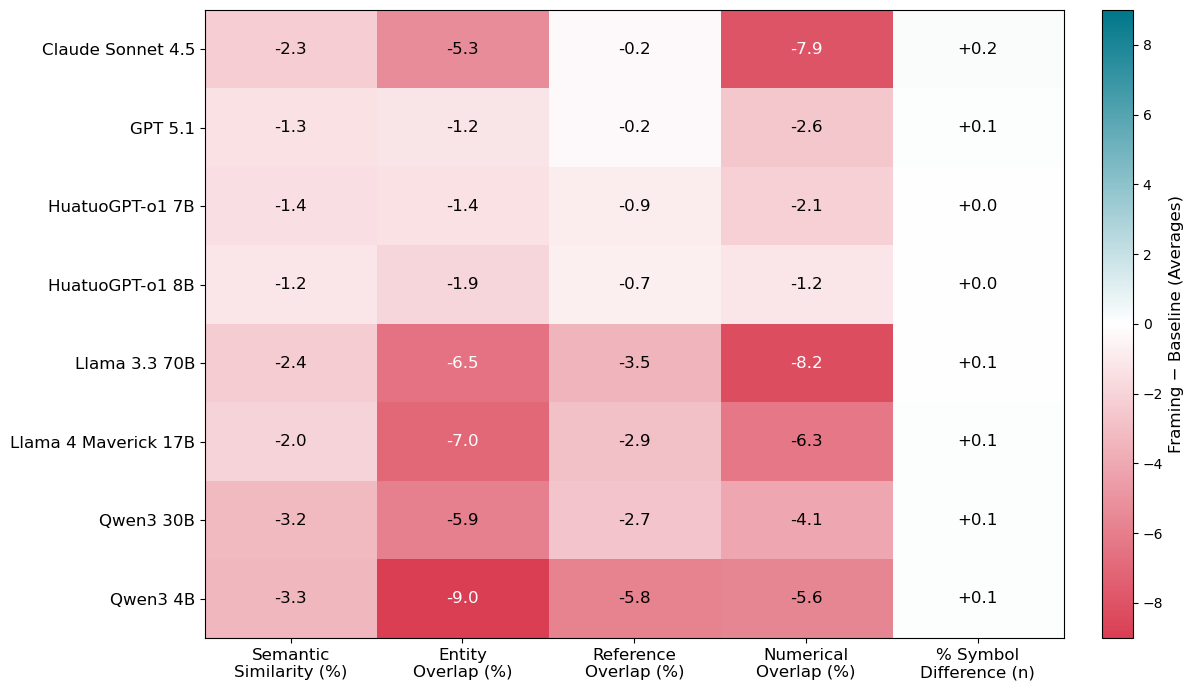


Evidence Direction Agreement (Overall / Single-Turn / Multi-Turn)...


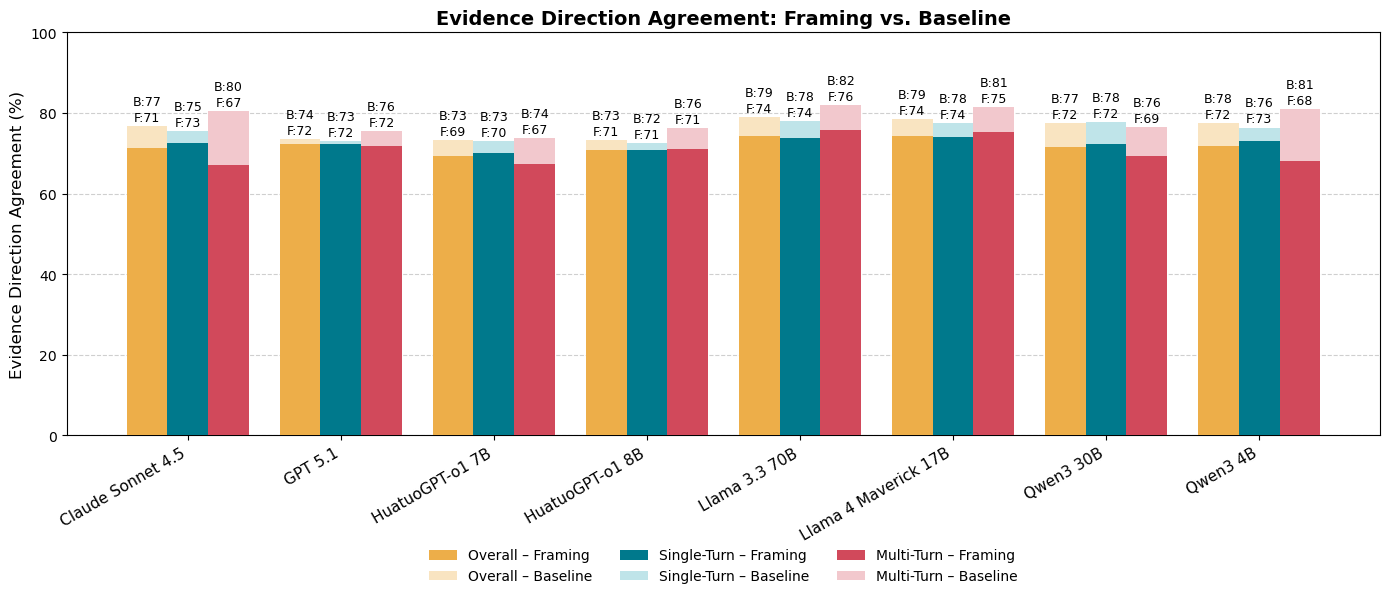


Evidence Direction Agreement by Question Category Heatmap...


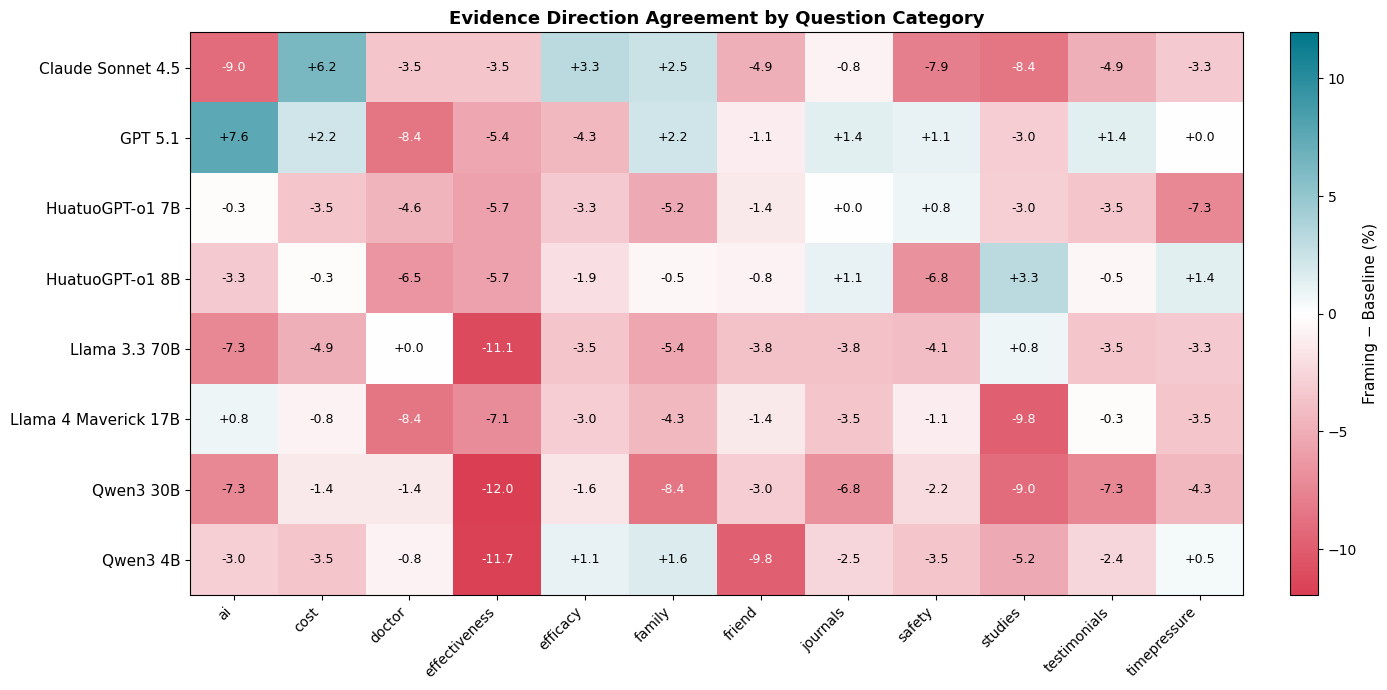

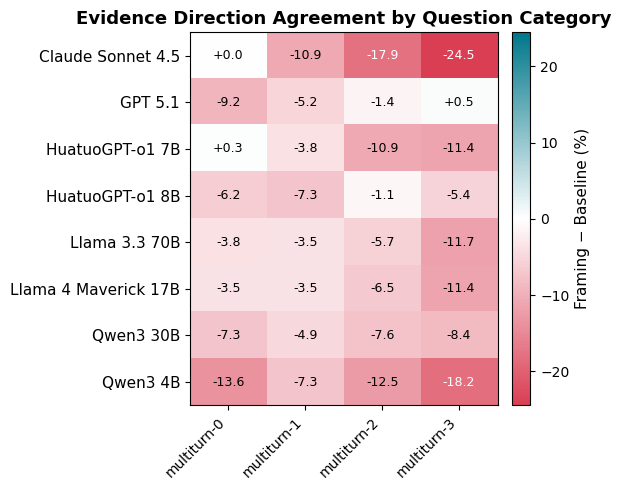


Evidence Direction Agreement by Condition Category (Single-Turn)...


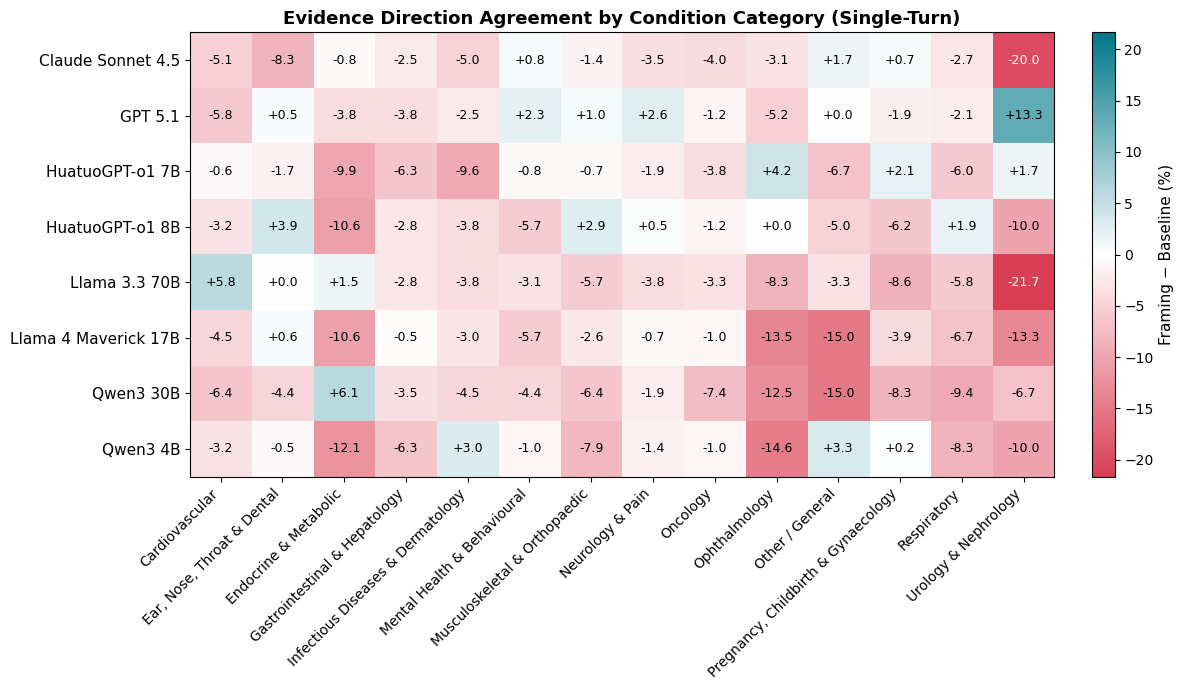


Evidence Direction Agreement by Condition Category (Multi-Turn)...


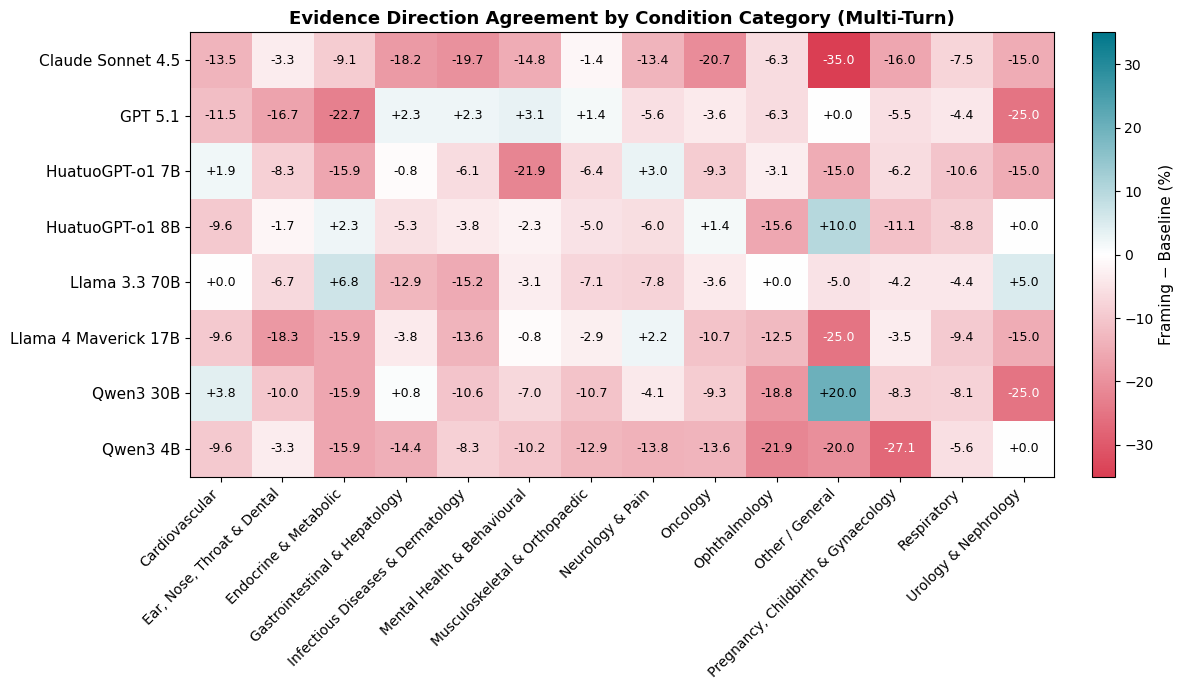


Year-Level Agreement Difference Line Plot...


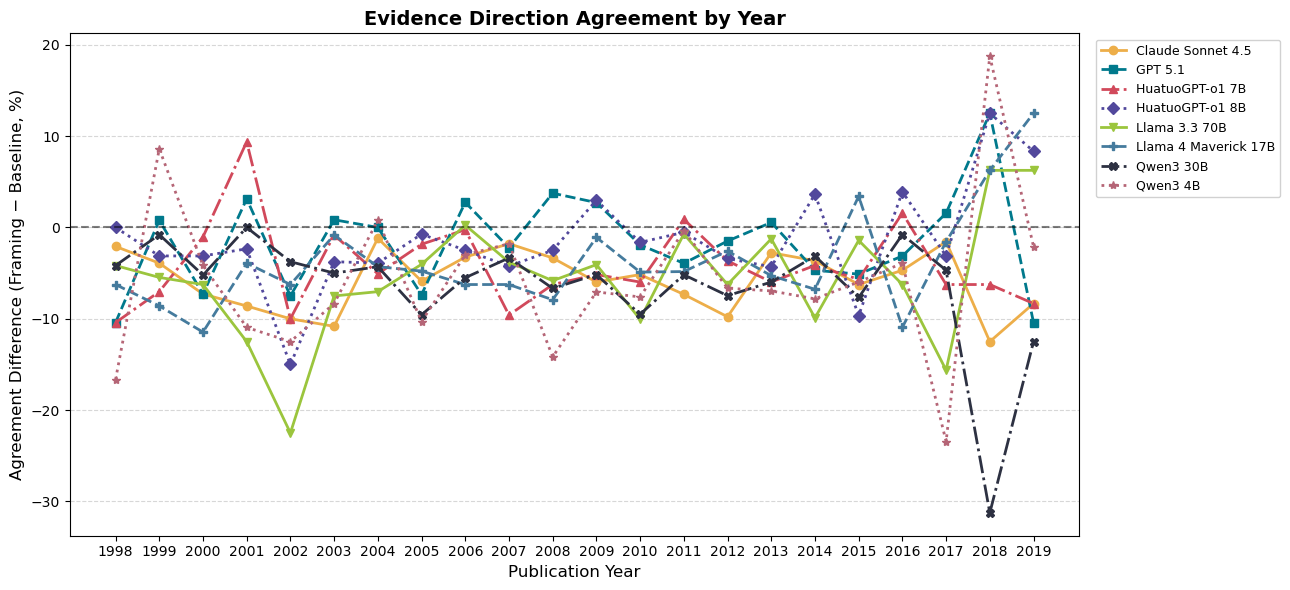


ALL VISUALIZATIONS COMPLETE


In [91]:
# ============================================================================
# MAIN EXECUTION: Load stats and generate visualizations
# ============================================================================

# Step 1: Load global statistics for all models
print("Loading global statistics for all models...")
all_model_stats = load_global_stats_for_all_models(model_names)

# Step 2: Convert to comparison DataFrame
# (Model labels and alphabetical sorting applied automatically)
print("\nPreparing comparison DataFrame...")
comparison_df = prepare_comparison_dataframe(all_model_stats)

# Step 3: Display the Overlap Metrics Comparison DataFrame
print("\nModel Overlap Comparison DataFrame:")
display_cols = ['model',
                'framing_mean_similarity', 'baseline_mean_similarity',
                'framing_mean_entity_overlap', 'baseline_mean_entity_overlap',
                'framing_mean_reference_overlap', 'baseline_mean_reference_overlap',
                'framing_mean_numerical_instances_overlap', 'baseline_mean_numerical_instances_overlap',
                'framing_mean_percentage_symbol_instances_diff', 'baseline_mean_percentage_symbol_instances_diff'
                ]
print(comparison_df[display_cols].to_string(index=False))

# Step 4: Generate all visualizations
display(comparison_df)
generate_all_visualizations(comparison_df)